# Feature Engineering

Battery : B0005

Objective :

Extract statistical features from discharge, charge and impedance experiments.

These features will later be used for training the SOC, SOH and RUL machine learning models.

## 1. Import Libraries

In [34]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [35]:
import pandas as pd
import numpy as np

In [36]:
from src.core.config import PROCESSED_DATA

## 2. Load Sample Experiments

In [37]:
discharge_file = (
    PROCESSED_DATA /
    "B0005" /
    "discharge" /
    "05122.csv"
)

charge_file = (
    PROCESSED_DATA /
    "B0005" /
    "charge" /
    "05123.csv"
)

impedance_file = (
    PROCESSED_DATA /
    "B0005" /
    "impedance" /
    "05161.csv"
)

In [38]:
discharge_df = pd.read_csv(discharge_file)

charge_df = pd.read_csv(charge_file)

impedance_df = pd.read_csv(impedance_file)

In [39]:
print("Discharge Shape :", discharge_df.shape)

print("Charge Shape :", charge_df.shape)

print("Impedance Shape :", impedance_df.shape)

Discharge Shape : (197, 6)
Charge Shape : (940, 6)
Impedance Shape : (48, 5)


## 3. Preview Data

In [40]:
display(discharge_df.head())

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922


In [41]:
display(charge_df.head())

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.325055,0.000302,29.341851,-0.002,0.003,0.000
1,3.001951,-3.361983,29.335723,-3.370,1.414,2.516
2,3.434644,1.508670,29.334717,1.498,4.142,5.500
3,3.454857,1.510043,29.341949,1.498,4.180,8.391
4,3.468788,1.508704,29.331462,1.498,4.196,11.266


In [42]:
display(impedance_df.head())

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,(-1+1j),(-1+1j),(1+0j),(-0.43892624830326377-0.107298295835479j),(0.07006937798290404-0.00047998469078178944j)
1,(820.6094970703125-36.23455047607422j),(337.0914611816406-82.9207763671875j),(2.3204145178633437+0.4633045948164565j),(0.13008840651776496-0.19711481029612374j),(0.06817886114940203-0.001190040925296937j)
2,(827.2421875-48.23122787475586j),(330.6315612792969-70.01371765136719j),(2.424192647592199+0.36746495469515333j),(0.058770560504133235+0.03330656583655633j),(0.06793257733714593-5.6826811936507056e-05j)
3,(827.1934814453125-56.195716857910156j),(330.8086242675781-61.73442459106445j),(2.4470021712116985+0.28677775364826635j),(0.0058135116366746726-0.060546548141956195j),(0.06691839226387165-0.0008787264015490232j)
4,(824.9295043945312-53.241477966308594j),(332.68267822265625-57.62901306152344j),(2.434304977711638+0.2616460702282485j),(0.12608106668700975-0.09044390544679616j),(0.06807105294348659-0.0001974802021297548j)


## 4. Test Feature Extraction

In [43]:
from src.feature_engineering.extractor import extract_features

In [44]:
discharge_features = extract_features(discharge_df)

len(discharge_features)

66

In [45]:
discharge_features

{'Voltage_measured_mean': np.float64(3.529828668852792),
 'Voltage_measured_std': np.float64(0.23655823618722582),
 'Voltage_measured_min': np.float64(2.612467348),
 'Voltage_measured_max': np.float64(4.191491808),
 'Voltage_measured_median': np.float64(3.529903338),
 'Voltage_measured_variance': np.float64(0.05595979910801132),
 'Voltage_measured_skewness': np.float64(-0.511719820017742),
 'Voltage_measured_kurtosis': np.float64(1.374830836846817),
 'Voltage_measured_rms': np.float64(3.537706343193162),
 'Voltage_measured_peak_to_peak': np.float64(1.5790244600000003),
 'Voltage_measured_energy': np.float64(2465.527135621819),
 'Current_measured_mean': np.float64(-1.818701964177665),
 'Current_measured_std': np.float64(0.595058403707573),
 'Current_measured_min': np.float64(-2.018014688),
 'Current_measured_max': np.float64(0.000728585),
 'Current_measured_median': np.float64(-2.012427485),
 'Current_measured_variance': np.float64(0.35409450382300495),
 'Current_measured_skewness': np.

## 5. Build Complete Feature Dataset

In [46]:
from src.feature_engineering.extractor import build_feature_datasets

In [47]:
charge_features, discharge_features, impedance_features = build_feature_datasets("B0005")


Processing CHARGE
Total Files : 170
Saved -> charge_features.csv

Processing DISCHARGE
Total Files : 168
Saved -> discharge_features.csv

Processing IMPEDANCE
Total Files : 278
Saved -> impedance_features.csv


In [48]:
charge_features.head()

,Voltage_measured_mean,Voltage_measured_std,Voltage_measured_min,Voltage_measured_max,Voltage_measured_median,Voltage_measured_variance,Voltage_measured_skewness,Voltage_measured_kurtosis,Voltage_measured_rms,Voltage_measured_peak_to_peak,...,Time_max,Time_median,Time_variance,Time_skewness,Time_kurtosis,Time_rms,Time_peak_to_peak,Time_energy,Experiment,File
0,4.058826,0.177474,3.001951,4.213016,4.139956,0.031497,-1.219373,1.694288,4.062701,1.211066,...,10516.000,2846.6170,9.600688e+06,0.614600,-0.877026,4813.751365,10516.000,2.178187e+10,charge,05123.csv
1,4.058139,0.175380,3.035879,4.212788,4.136345,0.030758,-1.138195,1.350919,4.061923,1.176909,...,10484.547,2828.7030,9.511406e+06,0.617134,-0.872393,4789.378680,10484.547,2.149304e+10,charge,05125.csv
2,4.058905,0.172699,3.066145,4.212924,4.134829,0.029825,-1.074096,1.094997,4.062573,1.146779,...,10397.890,2808.2340,9.347374e+06,0.616170,-0.872793,4749.856336,10397.890,2.104954e+10,charge,05127.csv
3,4.058330,0.173628,3.063766,4.212874,4.137383,0.030147,-1.083390,1.108522,4.062039,1.149108,...,10495.203,2828.9210,9.523425e+06,0.618018,-0.870207,4791.501854,10495.203,2.151211e+10,charge,05129.csv
4,4.059785,0.174176,3.059322,4.212764,4.149247,0.030337,-1.112106,1.172689,4.063516,1.153442,...,10792.672,2911.2345,1.010513e+07,0.615493,-0.876530,4933.808738,10792.672,2.317403e+10,charge,05131.csv


In [49]:
print(charge_features.shape)

(170, 68)


In [50]:
print(charge_features.info())

<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 68 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Voltage_measured_mean              170 non-null    float64
 1   Voltage_measured_std               170 non-null    float64
 2   Voltage_measured_min               170 non-null    float64
 3   Voltage_measured_max               170 non-null    float64
 4   Voltage_measured_median            170 non-null    float64
 5   Voltage_measured_variance          170 non-null    float64
 6   Voltage_measured_skewness          170 non-null    float64
 7   Voltage_measured_kurtosis          170 non-null    float64
 8   Voltage_measured_rms               170 non-null    float64
 9   Voltage_measured_peak_to_peak      170 non-null    float64
 10  Voltage_measured_energy            170 non-null    float64
 11  Current_measured_mean              170 non-null    float64
 12  Curre

In [51]:
discharge_features.head()

,Voltage_measured_mean,Voltage_measured_std,Voltage_measured_min,Voltage_measured_max,Voltage_measured_median,Voltage_measured_variance,Voltage_measured_skewness,Voltage_measured_kurtosis,Voltage_measured_rms,Voltage_measured_peak_to_peak,...,Time_max,Time_median,Time_variance,Time_skewness,Time_kurtosis,Time_rms,Time_peak_to_peak,Time_energy,Experiment,File
0,3.529829,0.236558,2.612467,4.191492,3.529903,0.055960,-0.511720,1.374831,3.537706,1.579024,...,3690.234,1796.3280,1.143344e+06,0.036016,-1.191117,2102.665265,3690.234,8.709766e+08,discharge,05122.csv
1,3.537320,0.235366,2.587209,4.189773,3.535737,0.055397,-0.554321,1.601887,3.545102,1.602564,...,3672.344,1787.6645,1.132459e+06,0.036092,-1.191289,2092.368772,3672.344,8.580894e+08,discharge,05124.csv
2,3.543737,0.228111,2.651917,4.188187,3.538223,0.052035,-0.442777,1.390431,3.551033,1.536270,...,3651.641,1778.8280,1.120237e+06,0.035156,-1.191666,2081.404351,3651.641,8.447876e+08,discharge,05126.csv
3,3.543666,0.233347,2.592948,4.188461,3.540233,0.054451,-0.552103,1.657322,3.551301,1.595513,...,3631.563,1769.5705,1.108411e+06,0.034785,-1.192466,2070.419301,3631.563,8.316074e+08,discharge,05128.csv
4,3.542343,0.237301,2.547420,4.188299,3.540603,0.056312,-0.628218,1.859679,3.550242,1.640879,...,3629.172,1768.3910,1.106929e+06,0.034509,-1.192190,2069.323686,3629.172,8.307275e+08,discharge,05130.csv


In [52]:
print(discharge_features.shape)

(168, 68)


In [53]:
print(discharge_features.info())

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 68 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Voltage_measured_mean              168 non-null    float64
 1   Voltage_measured_std               168 non-null    float64
 2   Voltage_measured_min               168 non-null    float64
 3   Voltage_measured_max               168 non-null    float64
 4   Voltage_measured_median            168 non-null    float64
 5   Voltage_measured_variance          168 non-null    float64
 6   Voltage_measured_skewness          168 non-null    float64
 7   Voltage_measured_kurtosis          168 non-null    float64
 8   Voltage_measured_rms               168 non-null    float64
 9   Voltage_measured_peak_to_peak      168 non-null    float64
 10  Voltage_measured_energy            168 non-null    float64
 11  Current_measured_mean              168 non-null    float64
 12  Curre

In [54]:
impedance_features.head()

,Experiment,File
0,impedance,05161.csv
1,impedance,05163.csv
2,impedance,05165.csv
3,impedance,05167.csv
4,impedance,05169.csv


In [55]:
print(impedance_features.shape)

(278, 2)


In [56]:
print(impedance_features.info())

<class 'pandas.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Experiment  278 non-null    str  
 1   File        278 non-null    str  
dtypes: str(2)
memory usage: 4.5 KB
None


In [57]:
charge_features.isnull().sum().sum()

np.int64(0)

In [58]:
discharge_features.isnull().sum().sum()

np.int64(0)

In [59]:
impedance_features.isnull().sum().sum()

np.int64(0)

In [60]:
summary = pd.DataFrame({

    "Experiment":[
        "Charge",
        "Discharge",
        "Impedance"
    ],

    "Samples":[
        len(charge_features),
        len(discharge_features),
        len(impedance_features)
    ]

})

summary

,Experiment,Samples
0,Charge,170
1,Discharge,168
2,Impedance,278


In [61]:
print(summary)

  Experiment  Samples
0     Charge      170
1  Discharge      168
2  Impedance      278


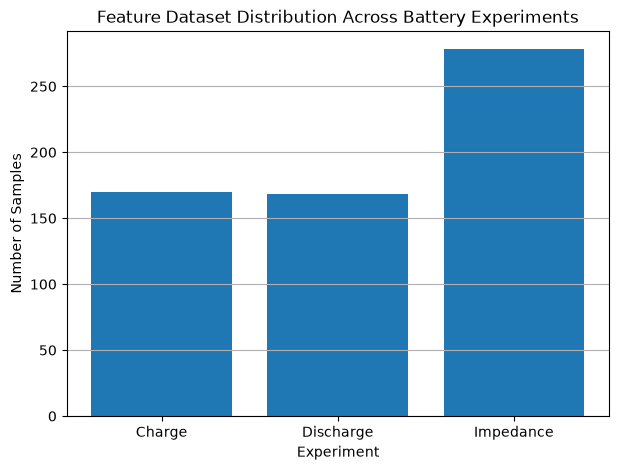

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    summary["Experiment"],
    summary["Samples"]
)

plt.title("Feature Dataset Distribution Across Battery Experiments")

plt.xlabel("Experiment")

plt.ylabel("Number of Samples")

plt.grid(axis="y")

plt.show()

# 6. Conclusion

Feature engineering successfully extracted statistical features
from Charge, Discharge and Impedance experiments.

Three separate feature datasets were generated:

• charge_features.csv

• discharge_features.csv

• impedance_features.csv

These datasets will now be used for

SOC prediction

SOH prediction

RUL prediction.